# **Matplotlib Format Charts**

In [1]:
# Import Libraries
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading the dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

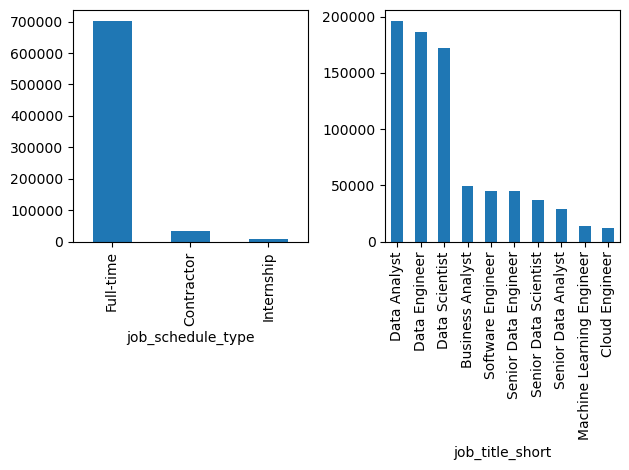

In [14]:
fig, ax = plt.subplots(1, 2)

df['job_title_short'].value_counts().plot(kind='bar', ax=ax[1])
df['job_schedule_type'].value_counts().head(3).plot(kind='bar', ax=ax[0])

fig.tight_layout()

# *Example of Top Skills in Job Postings*

In [16]:
df_skills = df.copy()
df_skills = df_skills.explode('job_skills')
skill_count = df_skills.groupby(['job_title_short', 'job_skills']).size()
df_skill_count = skill_count.reset_index(name='count')
df_skill_count.sort_values(by='count', ascending=False, inplace=True)

df_skill_count


,job_title_short,job_skills,count
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
625,Data Analyst,sql,92428
1101,Data Scientist,sql,78982
...,...,...,...
266,Cloud Engineer,delphi,1
1920,Senior Data Scientist,objective-c,1
1400,Senior Data Analyst,couchdb,1
298,Cloud Engineer,haskell,1


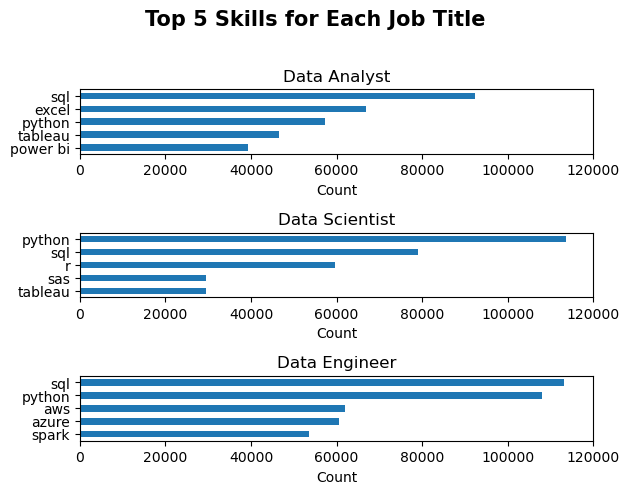

In [52]:
job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

fig, ax = plt.subplots(3, 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skill_count[df_skill_count['job_title_short'] == job_title].head(5)
    df_plot.plot(x='job_skills', y='count', kind='barh', ax=ax[i], title=job_title)
    ax[i].invert_yaxis()
    ax[i].set_xlabel('Count')
    ax[i].set_ylabel('')
    ax[i].legend().remove()
    ax[i].set_xlim(0, 120000)

fig.suptitle('Top 5 Skills for Each Job Title', y=1.02, fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()

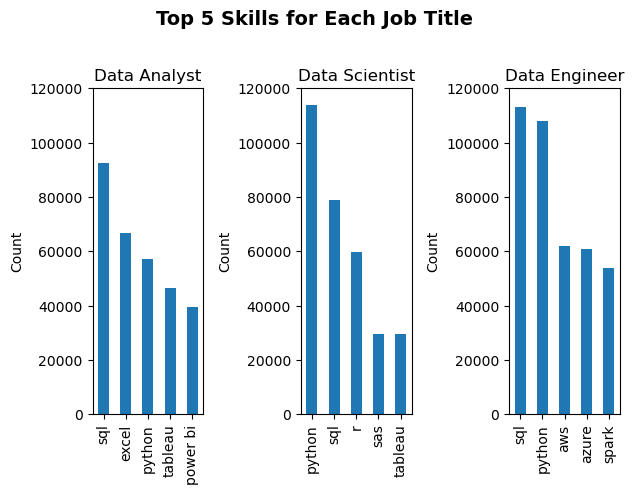

In [51]:
job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

fig, ax = plt.subplots(1, 3)

for i, job_title in enumerate(job_titles):
    df_plot = df_skill_count[df_skill_count['job_title_short'] == job_title].head(5)
    df_plot.plot(x='job_skills', y='count', kind='bar', ax=ax[i], title=job_title)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('Count')
    ax[i].set_ylim(0, 120000)
    ax[i].legend().remove()
fig.suptitle('Top 5 Skills for Each Job Title', y=1.02, fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()